<a href="https://colab.research.google.com/github/YYChang34/Image-Classification-with-CNN/blob/main/Image_Classification_with_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification with CNN

# Data Preprocessing


- Step 1:匯入CIFAR-10 dataset裡面總共有60000張影像並且分類成10個類別，分別為Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship 和 Truck，其中每張都是32x32 pixel的RGB影像。
- Step 2:將每張影像pixel值透過除以255來縮放至[0, 1]，有助於提高後續訓練模型的穩定性。
- Step 3:由於y_train和y_test標籤都是整數型態，因此需要將他們轉換成one-hot encoded vectors。
- Step 4:將dataset先分割成 80%train dataset & 20%validation dataset。
- Step 5:使用ImageDataGenerator對資料進行Data Augmentation，以此減少過擬合的風險，其中包括：
 - rotation_range=10: 隨機旋轉圖像範圍在 ±10 度之間
 - width_shift_range=0.05: 隨機平移圖像水平方向的範圍，最大為圖像寬度的 5%
 - height_shift_range=0.05: 隨機平移圖像垂直方向的範圍，最大為圖像高度的 5%
 - horizontal_flip=True: 隨機將圖像進行水平翻轉
 - zoom_range=0.05: 隨機縮放圖像，範圍為 ±5%




In [ ]:
import random
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"Training data shape after spliting : {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05
)

datagen.fit(X_train)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 10)
Test data shape: (10000, 32, 32, 3), Test labels shape: (10000, 10)
Training data shape after spliting : (40000, 32, 32, 3), Training labels shape: (40000, 10)
Validation data shape: (10000, 32, 32, 3), Validation labels shape: (10000, 10)


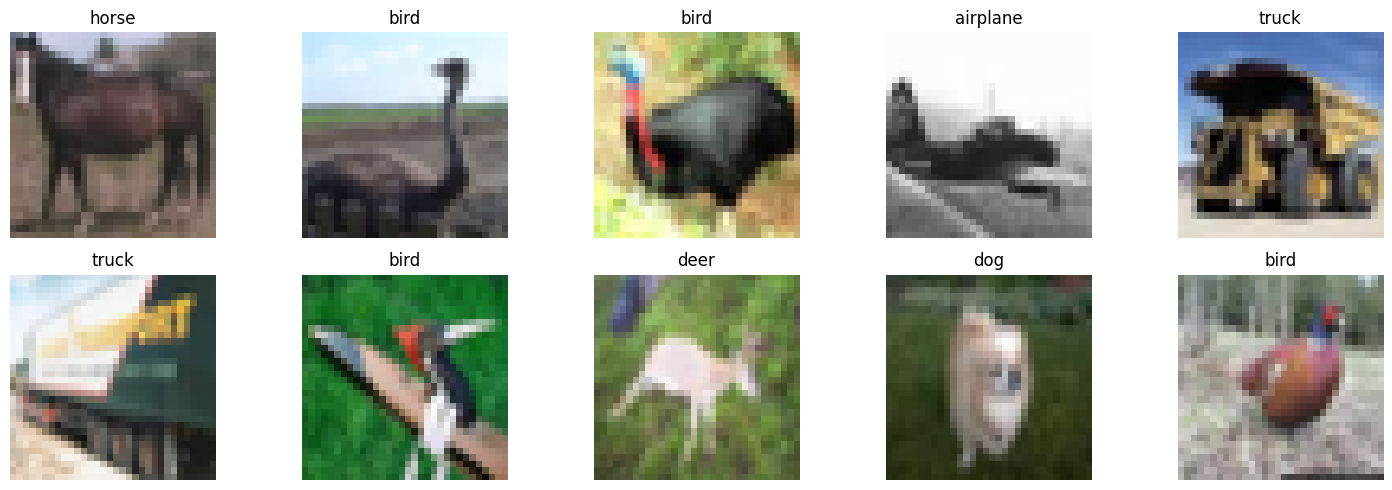

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

num_images = 10
random_indices = np.random.choice(len(X_train), num_images, replace=False)
sample_images = X_train[random_indices]
sample_labels = np.argmax(y_train[random_indices], axis=1)


plt.figure(figsize=(15, 5))
for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i])
    plt.title(class_names[sample_labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Model Implementation


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential()

#First Conv2D Block:
model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)))
model.add(layers.Activation('relu'))

model.add(layers.Conv2D(32, (3, 3)))
model.add(layers.Activation('relu'))

#MaxPooling2D:
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

#Second Conv2D Block:
model.add(layers.Conv2D(64, (3, 3), padding='same'))
model.add(layers.Activation('relu'))

model.add(layers.Conv2D(64, (5, 5)))
model.add(layers.Activation('relu'))

#MaxPooling2D and Dropout:
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

#Third Conv2D Block:
model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.Activation('relu'))

model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.Activation('relu'))

model.add(layers.MaxPooling2D(pool_size=(2, 2)))

#Flatten:
model.add(layers.Flatten())
model.add(layers.Dense(512))
model.add(layers.Activation('relu'))

#Output Layer:
model.add(layers.Dense(10))
model.add(layers.Activation('softmax'))

model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 30, 30, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 15, 15, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 5, 5, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 5, 5, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 620,330 (2.37 MB)

 Trainable params: 620,330 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

### Model Architecture

#### Input Layer:
- Conv2D Layer: 32 filters of size 3x3 with 'same' padding, input shape (32, 32, 3)
- Activation Function: ReLU
- Conv2D Layer: 32 filters of size 3x3
- Activation Function: ReLU
- MaxPooling2D Layer: Pool size (2, 2)

#### Hidden Layer 1:
- Conv2D Layer: 64 filters of size 3x3 with 'same' padding
- Activation Function: ReLU
- Conv2D Layer: 64 filters of size 5x5
- Activation Function: ReLU
- MaxPooling2D Layer: Pool size (2, 2)

#### Hidden Layer 2:
- Conv2D Layer: 128 filters of size 3x3 with 'same' padding
- Activation Function: ReLU
- Conv2D Layer: 128 filters of size 3x3 with 'same' padding
- Activation Function: ReLU
- MaxPooling2D Layer: Pool size (2, 2)

#### Flatten Layer:
- Flatten Layer: Flatten the 3D convolutional output into a 1D vector
- Dense Layer: 512 neurons
- Activation Function: ReLU

#### Output Layer:
- Dense Layer: 10 neurons (corresponding to 10 classes)
- Activation Function: Softmax

### Key Components

- Conv2D Layers：這些層是用來提取圖像特徵的卷積層，卷積核大小設定為 3x3 和 5x5，這樣可以提取不同範圍的局部特徵。

- ReLU Activation：這是一種非線性激活函數，使模型能夠學習複雜的非線性關係。

- MaxPooling2D Layers：用來減少圖像的空間大小，從而減少計算量，防止過擬合並保持重要的特徵。

- Flatten Layer：將卷積層的輸出展平為一維向量，這樣它就可以作為全連接層的輸入。

- Dense Layers：可以將每個神經元與前一層的所有神經元相連，用來學習更高層次的特徵，並進行最終的分類。

- Softmax Activation：可以將輸出轉換為概率分佈，並且確保所有類別的概率總和為1，使模型能夠進行多類別分類。

- Adam Optimizer：Adam 在訓練過程中自動調整每個參數的學習率，有助於提高訓練速度和模型的收斂性。

# Regularization Techniques

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import BatchNormalization

model = models.Sequential()

#First Conv2D Block:
model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)))
model.add(layers.Activation('relu'))

model.add(layers.Conv2D(32, (3, 3)))
model.add(layers.Activation('relu'))

#MaxPooling2D:
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))

#Second Conv2D Block:
model.add(layers.Conv2D(64, (3, 3), padding='same'))
model.add(layers.Activation('relu'))

model.add(layers.Conv2D(64, (3, 3)))
model.add(layers.Activation('relu'))

#MaxPooling2D and Dropout:
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))

#Flatten:
model.add(layers.Flatten())
model.add(layers.Dense(512))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.5))

#Output Layer:
model.add(layers.Dense(10))
model.add(layers.Activation('softmax'))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 30, 30, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 15, 15, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 13, 13, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           5,130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_13 (Activation)           │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

### Dropout
- **目的**：Dropout 是一種隨機丟棄神經元的Regularization Technique，它會隨機選擇神經元在每次訓練迭代中不參與計算，使得模型在訓練過程中不會過於依賴某些特定的神經元。主要透過隨機丟棄一部分神經元，避免模型過度依賴某些特徵，從而減少發生過度擬合風險。
- **使用位置**：
  - 第一層 MaxPooling2D 後：在第一次MaxPooling後加入了 0.25 的 Dropout，這表示在每次訓練過程中，有 25% 的神經元會被丟棄。
  - 第二層 MaxPooling2D 後：同樣在第二次MaxPooling後也加入了 0.25 的 Dropout。
  - 全連接層（Dense Layer）後：在Flatten之後，將Dense layer的神經元數設為 512，並且加上 0.5 的 Dropout，這表示會有 50% 的神經元被丟棄，這樣可以防止模型對訓練數據的過度擬合，從而提升模型的Generation能力。

# Training and Evaluation

In [ ]:
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val),
    shuffle=True ,
    callbacks=[early_stopping]
)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 240s 380ms/step - accuracy: 0.2996 - loss: 1.8960 - val_accuracy: 0.5243 - val_loss: 1.3439
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 218s 348ms/step - accuracy: 0.5212 - loss: 1.3411 - val_accuracy: 0.6078 - val_loss: 1.0770
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 217s 346ms/step - accuracy: 0.5782 - loss: 1.1809 - val_accuracy: 0.6440 - val_loss: 1.0057
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 342ms/step - accuracy: 0.6106 - loss: 1.1001 - val_accuracy: 0.6679 - val_loss: 0.9552
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 281s 374ms/step - accuracy: 0.6375 - loss: 1.0252 - val_accuracy: 0.6700 - val_loss: 0.9617
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 244s 344ms/step - accuracy: 0.6603 - loss: 0.9678 - val_accuracy: 0.6923 - val_loss: 0.8730
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 264s 347ms/step - accuracy: 0.6733 - loss: 0.9259 - val_accuracy: 0.6880 - val_loss: 0.9102
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 262s 346ms/step - accuracy: 0.6860 - loss: 0.89

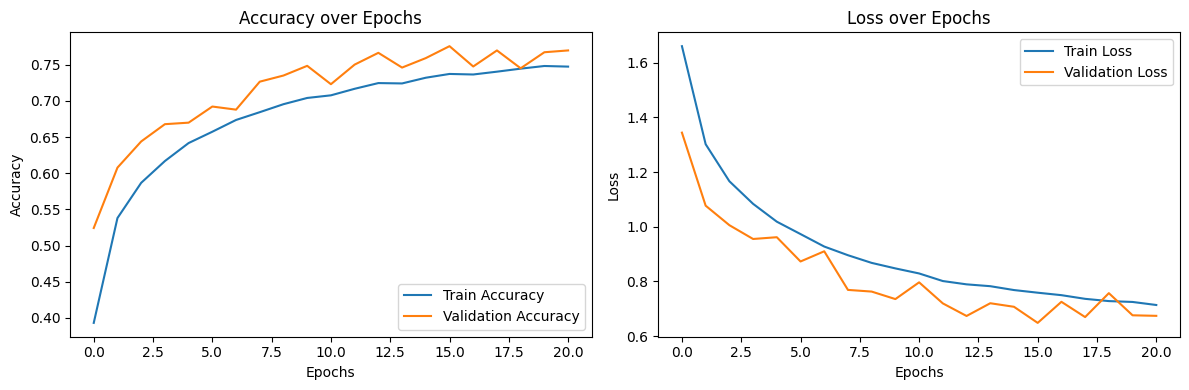

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step
Test Accuracy: 0.7689
Test Loss: 0.6639

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      1000
           1       0.87      0.92      0.89      1000
           2       0.77      0.60      0.67      1000
           3       0.66      0.51      0.57      1000
           4       0.70      0.74      0.72      1000
           5       0.72      0.62      0.66      1000
           6       0.71      0.90      0.80      1000
           7       0.80      0.82      0.81      1000
           8       0.86      0.86      0.86      1000
           9       0.79      0.91      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.76     10000
weighted avg       0.77      0.77      0.76     10000



# Report




### Model Architecture

這個模型是一個卷積神經網絡（CNN），用來處理 CIFAR-10 圖像分類問題。以下是模型的結構：

1. **Conv2D Layer**：
   - 模型有兩個卷積區塊，每個區塊包含兩層卷積層。卷積層用來提取圖像的空間特徵。
   - 第一次卷積區塊使用 32 個 3x3 的卷積核，第二次卷積區塊使用 64 個 3x3 的卷積核。

2. **ReLU**：
   - 在每個卷積層之後使用 ReLU Activation，這是一個非線性激活函數，能夠有效捕捉非線性特徵，並且避免梯度消失問題。

3. **MaxPooling2D Layer**：
   - 每個卷積區塊之後，使用 MaxPooling Layer 來縮小圖像的空間大小，減少計算量，同時保留重要特徵。
   
4. **Dropout**：
   - 在每個Pooling Layer後面使用 Dropout 層來防止過擬合。第一次 Dropout 使用 25%（丟棄 25% 的神經元），第二次 Dropout 也使用 25%。在 Dense Layer 後面使用更高的 50% Dropout，這有助於避免過擬合。

5. **Flatten Layer與Dense Layer**：
   - 在經過 Convolution Layer 和 Pooling Layer 後，將多維的輸出展平為一維，然後輸入至一個具有 512 個神經元的 Dense Layer,這一層使用 ReLU Activation 來學習高層次的特徵。

6. **Output Layer**：
   - 最後，使用 10 個神經元的輸出層對 10 類進行分類，並且使用 Softmax Activation 來獲得每個類別的概率分佈。

### Regularization Techniques

1. **Dropout**：
   - Dropout 用來減少過擬合，透過隨機丟棄神經元來減少模型對某些特徵的依賴，從而提高模型的
   Generation 能力。
   
2. **早期停止（EarlyStopping）**：
   - 在訓練過程中使用早期停止來避免過擬合，根據 Valiation Loss 來停止訓練，若連續 5 個 epoch 中損失沒有改善，則停止訓練並恢復最佳權重。

### Hyperparameter Choices

1. **Optimizer（Adam）**：
   - Adam 能夠有效地加速訓練並提升模型性能。
   
2. **Loss Funtion（Categorical Crossentropy）**：
   - 由於是多類別分類問題，選擇使用 `categorical_crossentropy` 作為損失函數，這能夠有效地處理多類別問題。
   
3. **Batch Size**：
   - 使用批次大小為 64，適合在大多數情況下達到良好的性能。

4. **Callbacks**：
   - 使用 `EarlyStopping` 來避免過擬合並自動停止訓練，選擇監控 `val_loss` 來確保訓練過程不會過度擬合。

### Learning Curves

- **Accuracy**：
   - Training：隨著 epoch 數的增加，Training 準確率逐漸提高，並且在大約前 10-15 個 epoch 內提升較為明顯，因為模型在訓練過程中學習到特徵並開始有好的表現。
   - Validation：learning curve 的變化呈現上升趨勢，但與 Training 相比，Validation 準確率的增長速度較慢，並且在大約第 25 個 epoch 時開始出現平緩或波動。
   
- **Loss**：
   - Training：隨著訓練的進行，Training 損失逐步減少，顯示出模型在訓練集上的擬合程度越來越好。
   - Validation：Validation 損失在一開始也有明顯下降，但是在下降過程中突然的再上升，可能是發生過擬合的情況。

### Result
- **Test Accuracy**: 0.7689
- **Test Loss**：0.6639
- **Classification Report**：
   - 較高表現類別：
      - Ｃlass 1：precision 0.87，recall 0.92，F1-score 0.89，顯示該類別的預測表現非常好，尤其是 recall 高，意味著大部分屬於 Class 1 的樣本都能被成功識別。
      - Ｃlass 8：precision 0.86，recall 0.86，F1-score 0.86，顯示該類別的預測也非常穩定。
      - Ｃlass 9：precision 0.79，recall 0.91，F1-score 0.85，該類別也有較高的 recall，顯示模型對此類別的識別能力較強。
   - 較低表現類別：
      - Ｃlass 2：precision 0.77，recall 0.60，F1-score 0.67，recall 較低，模型未能充分識別出所有的 Class 2 樣本。
      - Ｃlass 3：precision 0.66，recall 0.51，F1-score 0.57，這是表現最差的類別，低 recall 值代表模型對這個類別的識別不夠好。
      - Ｃlass 5：precision 0.87，recall 0.92，F1-score 0.89，儘管 precision 不錯，但 recall 較低，表明有很多正確的 Class 5 被錯誤分類。